# 02 — Cleaning, feature engineering, and EDA

Takes the saved raw extract from `01_api_download_sample.ipynb` and produces:

1. **Hybrid target derivation** — derive `construction_era` and `pre_post_1975` from `annee_construction` where available, and fall back to `periode_construction` string when the exact year is missing. The regression target (`annee_construction`) keeps only the rows with exact year. 
2. **Engineered features** : `heating_to_hot_water_ratio`, `energy_per_floor`, `all_electric`, `climate_heating_combo`, `insulation_indicator`.
3. **Outlier filtering** with a row-drop log: surface ∈ [10, 500] m², floors ∈ [1, 20].
4. **EDA**: year distribution, era + binary class balance, missingness heatmap, correlation heatmap, geographic distribution.
5. **Imputation + encoding**: median (numeric) and mode (categorical), ordinal-encoded matrix for tree models and one-hot + scaled matrix for linear models.
6. **Stratified 80/20 train/test split** on the era target so all downstream notebooks share the same hold-out.
7. **Save** model-ready and target parquets + cleaning log CSV to `data/cleaned/`.

In [6]:
import re
import unicodedata
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

In [7]:
RAW_PATH = Path("../data/raw/dpe_logements_1000000.parquet")
CLEAN_DIR = Path("../data/cleaned")
FIG_DIR = Path("../figures")
CLEAN_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SIZE = 0.2

TARGET_YEAR = "annee_construction"
TARGET_ERA = "construction_era"
TARGET_BINARY = "pre_post_1975"
LEAKY_PERIOD_COLUMN = "periode_construction"  # used for target derivation only; never a feature

ERA_LABELS = ["pre-1948", "1948-1974", "1975-1988", "1989-2000", "2001-2012", "2013+"]
BINARY_LABELS = ["pre-1975", "post-1975"]

In [8]:
df = pd.read_parquet(RAW_PATH)
print(f"Loaded {RAW_PATH}: {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded ../data/raw/dpe_logements_1000000.parquet: 1,000,000 rows x 228 columns


## Feature catalogue

Three feature groups, plus engineered features added below. The construction year (`annee_construction`) and binned `periode_construction` are **never** used as model features — they are only used to derive the targets.

In [9]:
ENERGY_FEATURES = [
    "conso_5_usages_par_m2_ep",        # kWh/m2/year - standardised total
    "emission_ges_5_usages_par_m2",    # kg CO2/m2/year
    "etiquette_dpe",                   # A-G label (ordinal)
    "etiquette_ges",                   # A-G label (ordinal)
    "conso_chauffage_ep",              # kWh/m2/year heating
    "conso_ecs_ep",                    # kWh/m2/year hot water
    "conso_refroidissement_ep",        # kWh/m2/year cooling
    "conso_eclairage_ep",              # kWh/m2/year lighting (post-2021 only)
    "conso_auxiliaires_ep",            # kWh/m2/year auxiliaries (post-2021 only)
]

STRUCTURAL_FEATURES = [
    "surface_habitable_logement",      # m2 habitable surface
    "type_batiment",                   # maison vs. appartement
    "nombre_niveau_logement",          # number of floors
    "qualite_isolation_murs",          # wall insulation quality
    "qualite_isolation_menuiseries",   # window glazing type
    "type_generateur_chauffage_principal",  # heating system type
    "type_energie_principale_chauffage",    # heating energy
    "type_installation_ecs",           # hot water system type
    "type_energie_principale_ecs",     # hot water energy type
    "type_ventilation",                # natural vs. mechanical ventilation
    "isolation_toiture",               # roof insulation
    "qualite_isolation_plancher_bas",  # floor insulation
    "classe_inertie_batiment",         # thermal mass / inertia class
]

GEO_FEATURES = [
    "code_departement_ban",   # French department code
    "zone_climatique",        # climate zone (H1, H2, H3)
    "classe_altitude",        # altitude category
]

BASE_FEATURES = ENERGY_FEATURES + STRUCTURAL_FEATURES + GEO_FEATURES
print(f"Base features: {len(BASE_FEATURES)} ({len(ENERGY_FEATURES)} energy, {len(STRUCTURAL_FEATURES)} structural, {len(GEO_FEATURES)} geo)")

Base features: 25 (9 energy, 13 structural, 3 geo)


## Hybrid target derivation 

`annee_construction` is missing for ~40% of rows but gives us the exact year. `periode_construction` is 100% complete but pre-binned. We use the exact year when available and fall back to mapping the period string for the remaining rows. This keeps the full ~50k for era / binary classification while keeping regression honest (it only uses rows with exact year).

The mapping uses regex to extract the start year from any period string and bins it into the spec's six era classes.

In [10]:
def _normalize(s):
    if pd.isna(s):
        return None
    s = str(s).strip().lower()
    s = "".join(c for c in unicodedata.normalize("NFD", s) if unicodedata.category(c) != "Mn")
    return s


def year_to_era(year):
    if pd.isna(year):
        return None
    if year < 1948:
        return "pre-1948"
    if year <= 1974:
        return "1948-1974"
    if year <= 1988:
        return "1975-1988"
    if year <= 2000:
        return "1989-2000"
    if year <= 2012:
        return "2001-2012"
    return "2013+"


def period_to_era(period):
    # Map ADEME periode_construction strings (e.g. '1948-1974', 'avant 1948', '2013-2021') to era bins
    s = _normalize(period)
    if s is None:
        return None
    if "avant 1948" in s:
        return "pre-1948"
    m = re.search(r"(\d{4})", s)
    if m:
        return year_to_era(int(m.group(1)))
    if "apres" in s:
        return "2013+"
    return None


# Coerce year to numeric; null out implausible values
df[TARGET_YEAR] = pd.to_numeric(df[TARGET_YEAR], errors="coerce")
year_valid = df[TARGET_YEAR].between(1000, pd.Timestamp.today().year, inclusive="both")
df.loc[~year_valid, TARGET_YEAR] = np.nan

# Derive era from year first, period second
era_from_year = df[TARGET_YEAR].map(year_to_era)
era_from_period = df[LEAKY_PERIOD_COLUMN].map(period_to_era)
df[TARGET_ERA] = pd.Categorical(
    era_from_year.where(era_from_year.notna(), era_from_period),
    categories=ERA_LABELS, ordered=True,
)
df["target_source"] = np.where(
    era_from_year.notna(), "annee_construction",
    np.where(era_from_period.notna(), "periode_construction", "missing"),
)

# Binary target from era
df[TARGET_BINARY] = np.where(
    df[TARGET_ERA].isin(["pre-1948", "1948-1974"]), "pre-1975",
    np.where(df[TARGET_ERA].notna(), "post-1975", None),
)

print("Target derivation source breakdown:")
print(df["target_source"].value_counts(dropna=False).to_string())
print()
print(f"Era coverage:            {df[TARGET_ERA].notna().sum():>7,} / {len(df):,} ({df[TARGET_ERA].notna().mean():.1%})")
print(f"Regression-usable rows:  {df[TARGET_YEAR].notna().sum():>7,} ({df[TARGET_YEAR].notna().mean():.1%})")
print(f"Rows recovered via period fallback: {(df['target_source'] == 'periode_construction').sum():,}")

Target derivation source breakdown:
target_source
annee_construction      875796
periode_construction    124204

Era coverage:            1,000,000 / 1,000,000 (100.0%)
Regression-usable rows:  875,796 (87.6%)
Rows recovered via period fallback: 124,204


## Engineered features

Five derived features. Each is computed safely (NaN where source data is missing or denominators are zero) and added to `ALL_FEATURES`.

In [11]:
def safe_ratio(num, den):
    den_safe = den.where(den > 0)
    return num / den_safe


# 1. Heating-to-hot-water ratio
df["heating_to_hot_water_ratio"] = safe_ratio(df["conso_chauffage_ep"], df["conso_ecs_ep"])

# 2. Energy per floor
df["energy_per_floor"] = safe_ratio(
    df["conso_5_usages_par_m2_ep"],
    pd.to_numeric(df["nombre_niveau_logement"], errors="coerce"),
)

# 3. All-electric flag (heating energy contains 'electric')
ELECTRIC_KEYWORDS = ["electric", "electrique"]


def is_all_electric(s):
    norm = _normalize(s)
    if norm is None:
        return np.nan
    return int(any(k in norm for k in ELECTRIC_KEYWORDS))


df["all_electric"] = df["type_energie_principale_chauffage"].map(is_all_electric)

# 4. Climate zone x heating-type interaction (categorical combo)
df["climate_heating_combo"] = (
    df["zone_climatique"].astype(str).where(df["zone_climatique"].notna(), "NA")
    + "__"
    + df["type_energie_principale_chauffage"].astype(str).where(df["type_energie_principale_chauffage"].notna(), "NA")
)
df.loc[
    df["zone_climatique"].isna() | df["type_energie_principale_chauffage"].isna(),
    "climate_heating_combo",
] = np.nan

# 5. Insulation indicator: average ordinal score across wall / roof / floor quality columns
QUALITY_MAP = {
    _normalize(k): v for k, v in {
        "tres bonne": 4, "bonne": 3, "moyenne": 2, "insuffisante": 1, "non isole": 0,
    }.items()
}


def quality_to_score(s):
    norm = _normalize(s)
    if norm is None:
        return np.nan
    return QUALITY_MAP.get(norm, np.nan)


_ins_cols = ["qualite_isolation_murs", "qualite_isolation_plancher_bas", "isolation_toiture"]
_ins_scores = pd.DataFrame({c: df[c].map(quality_to_score) for c in _ins_cols})
df["insulation_indicator"] = _ins_scores.mean(axis=1, skipna=True)

ENGINEERED_FEATURES = [
    "heating_to_hot_water_ratio",
    "energy_per_floor",
    "all_electric",
    "climate_heating_combo",
    "insulation_indicator",
]
ALL_FEATURES = BASE_FEATURES + ENGINEERED_FEATURES
print(f"Total features after engineering: {len(ALL_FEATURES)} (added {len(ENGINEERED_FEATURES)} derived)")
df[ENGINEERED_FEATURES].describe(include="all").T[["count", "mean", "std", "min", "max"]]

Total features after engineering: 30 (added 5 derived)


,count,mean,std,min,max
heating_to_hot_water_ratio,997376.0,713.776866,15751.623316,0.0,2228372.0
energy_per_floor,990585.0,193.449474,586.965345,0.044219,550768.028571
all_electric,1000000.0,0.665601,0.47178,0.0,1.0
climate_heating_combo,962684,NaN,NaN,NaN,NaN
insulation_indicator,999984.0,2.10553,0.907269,1.0,4.0


## Cleaning pipeline

Per the spec: drop rows whose era target couldn't be derived (from either source), and drop rows with implausible surface or floor counts. Each step's row-drop count is logged.

In [12]:
SURFACE_COL = "surface_habitable_logement"
FLOORS_COL = "nombre_niveau_logement"

# Coerce numeric columns used in filters
df[SURFACE_COL] = pd.to_numeric(df[SURFACE_COL], errors="coerce")
df[FLOORS_COL] = pd.to_numeric(df[FLOORS_COL], errors="coerce")

cleaning_log = []
start_rows = len(df)
df_clean = df.copy()


def drop_and_log(data, mask_to_keep, step, reason):
    before = len(data)
    cleaned = data.loc[mask_to_keep].copy()
    dropped = before - len(cleaned)
    cleaning_log.append({
        "step": step,
        "reason": reason,
        "rows_before": before,
        "rows_dropped": dropped,
        "rows_after": len(cleaned),
        "dropped_pct_of_previous": round(100 * dropped / before, 2) if before else 0,
        "dropped_pct_of_start": round(100 * dropped / start_rows, 2),
    })
    return cleaned


df_clean = drop_and_log(
    df_clean,
    df_clean[TARGET_ERA].notna(),
    "era_target",
    "construction era could not be derived from year or period",
)
df_clean = drop_and_log(
    df_clean,
    df_clean[SURFACE_COL].between(10, 500, inclusive="both"),
    "surface",
    "surface_habitable_logement outside [10, 500] m^2 (NaN also dropped)",
)
df_clean = drop_and_log(
    df_clean,
    df_clean[FLOORS_COL].isna() | df_clean[FLOORS_COL].between(1, 20, inclusive="both"),
    "floors",
    "nombre_niveau_logement outside [1, 20]; NaN kept for imputation",
)

cleaning_report = pd.DataFrame(cleaning_log)
print(f"Rows before cleaning: {start_rows:,}")
print(f"Rows after cleaning:  {len(df_clean):,}")
print(f"Total dropped:        {start_rows - len(df_clean):,} ({(1 - len(df_clean) / start_rows) * 100:.2f}%)")
cleaning_report

Rows before cleaning: 1,000,000
Rows after cleaning:  993,083
Total dropped:        6,917 (0.69%)


,step,reason,rows_before,rows_dropped,rows_after,dropped_pct_of_previous,dropped_pct_of_start
0,era_target,construction era could not be derived from yea...,1000000,0,1000000,0.00,0.00
1,surface,"surface_habitable_logement outside [10, 500] m...",1000000,6562,993438,0.66,0.66
2,floors,"nombre_niveau_logement outside [1, 20]; NaN ke...",993438,355,993083,0.04,0.04


## EDA

Plots saved to `figures/` and rendered inline. All EDA runs on the cleaned dataframe (`df_clean`).

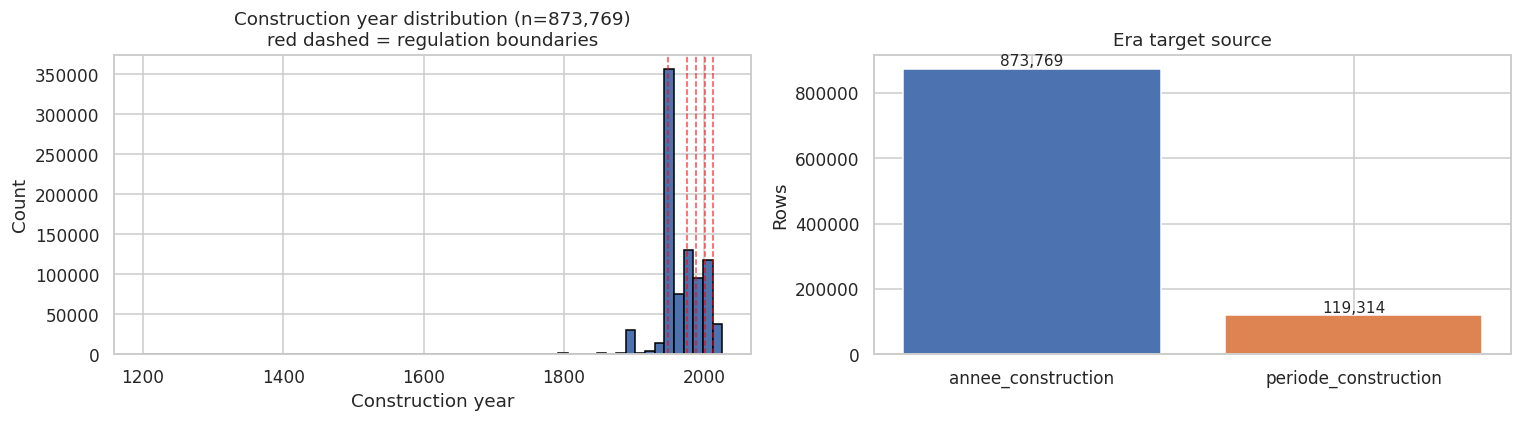

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
years = df_clean[TARGET_YEAR].dropna()
ax.hist(years, bins=60, edgecolor="black", color="#4c72b0")
for boundary in [1948, 1975, 1989, 2001, 2013]:
    ax.axvline(boundary, color="red", linestyle="--", linewidth=1, alpha=0.7)
ax.set_xlabel("Construction year")
ax.set_ylabel("Count")
ax.set_title(f"Construction year distribution (n={len(years):,})\nred dashed = regulation boundaries")

ax = axes[1]
source_counts = df_clean["target_source"].value_counts()
ax.bar(source_counts.index, source_counts.values, color=["#4c72b0", "#dd8452", "#999"])
ax.set_title("Era target source")
ax.set_ylabel("Rows")
for i, v in enumerate(source_counts.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=10)

fig.tight_layout()
fig.savefig(FIG_DIR / "year_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

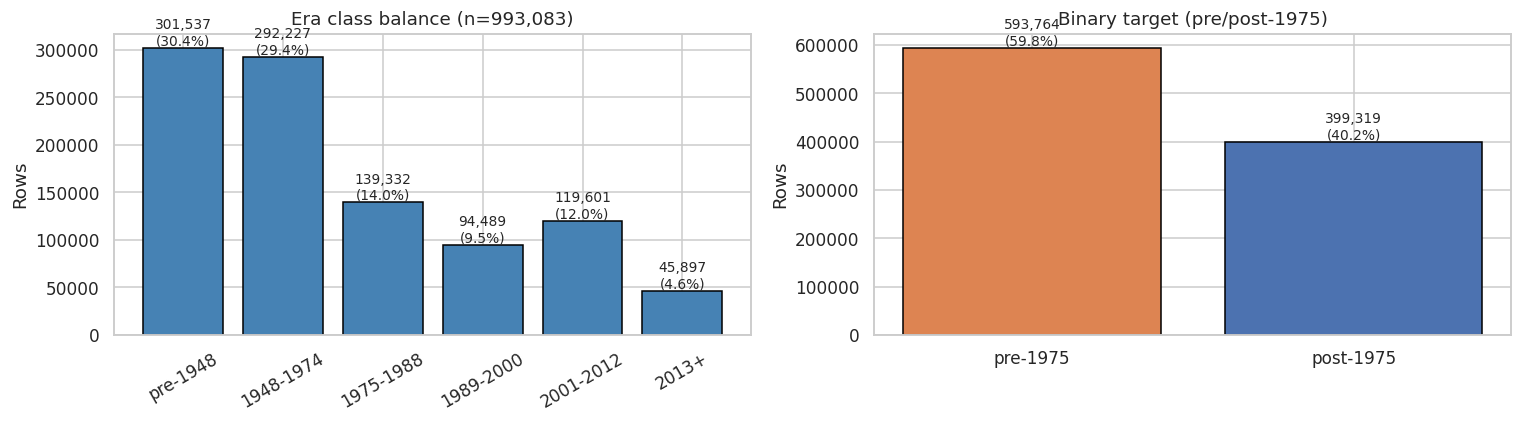

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
era_counts = df_clean[TARGET_ERA].value_counts(sort=False).reindex(ERA_LABELS).fillna(0).astype(int)
ax.bar(era_counts.index, era_counts.values, color="steelblue", edgecolor="black")
ax.set_title(f"Era class balance (n={len(df_clean):,})")
ax.set_ylabel("Rows")
ax.tick_params(axis="x", rotation=30)
for i, v in enumerate(era_counts.values):
    pct = 100 * v / len(df_clean)
    ax.text(i, v, f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

ax = axes[1]
binary_counts = df_clean[TARGET_BINARY].value_counts().reindex(BINARY_LABELS).fillna(0).astype(int)
ax.bar(binary_counts.index, binary_counts.values, color=["#dd8452", "#4c72b0"], edgecolor="black")
ax.set_title("Binary target (pre/post-1975)")
ax.set_ylabel("Rows")
for i, v in enumerate(binary_counts.values):
    pct = 100 * v / len(df_clean)
    ax.text(i, v, f"{v:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(FIG_DIR / "class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

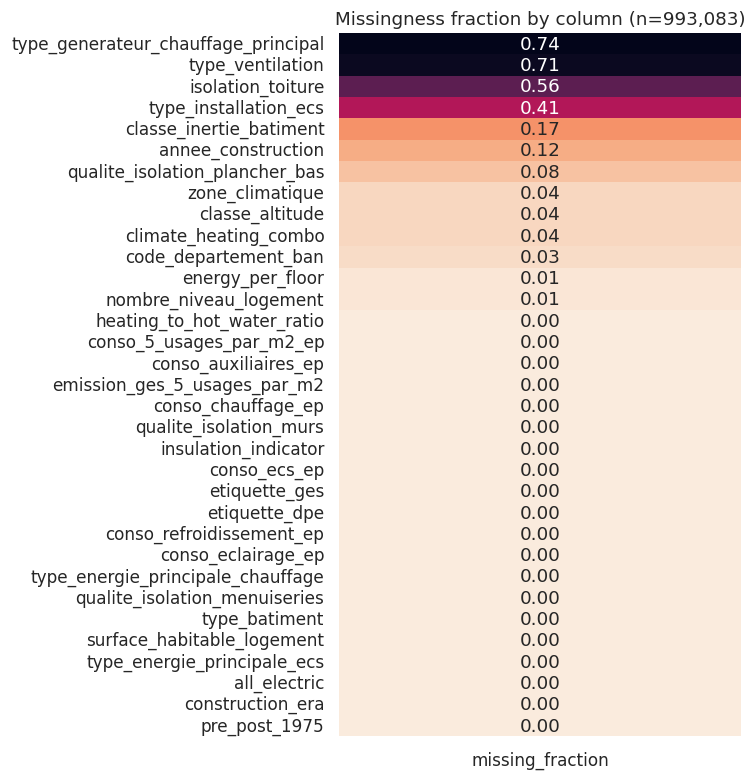

In [15]:
subset_for_missing = BASE_FEATURES + ENGINEERED_FEATURES + [TARGET_YEAR, TARGET_ERA, TARGET_BINARY]
miss = df_clean[subset_for_missing].isna().mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, max(4, len(miss) * 0.22)))
sns.heatmap(
    miss.to_frame(name="missing_fraction"),
    annot=True, fmt=".2f", cmap="rocket_r", cbar=False, ax=ax,
)
ax.set_title(f"Missingness fraction by column (n={len(df_clean):,})")
fig.tight_layout()
fig.savefig(FIG_DIR / "missingness.png", dpi=120, bbox_inches="tight")
plt.show()

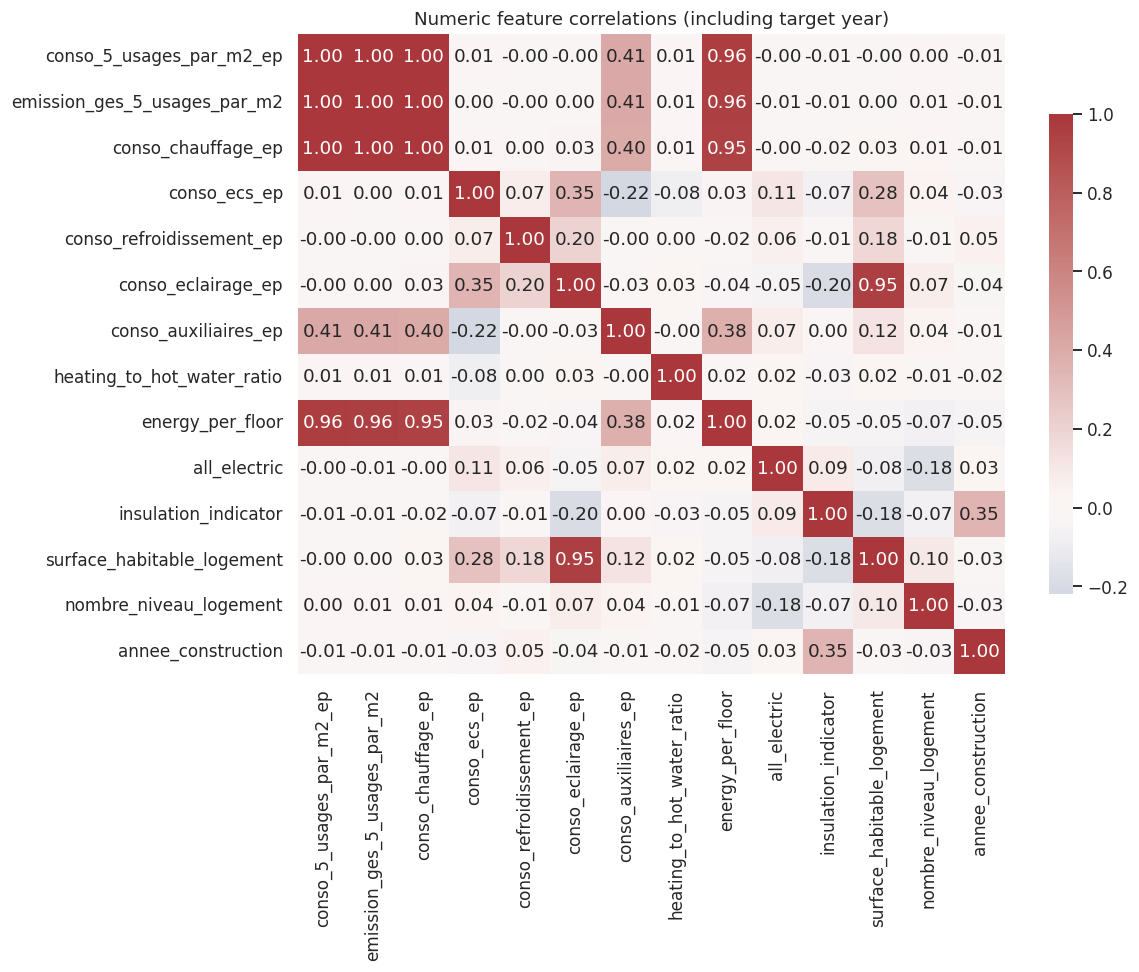

In [16]:
numeric_for_corr = [
    c for c in ENERGY_FEATURES + ENGINEERED_FEATURES + [SURFACE_COL, FLOORS_COL]
    if c in df_clean.columns and pd.api.types.is_numeric_dtype(df_clean[c])
]
corr = df_clean[numeric_for_corr + [TARGET_YEAR]].apply(pd.to_numeric, errors="coerce").corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Numeric feature correlations (including target year)")
fig.tight_layout()
fig.savefig(FIG_DIR / "correlation_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

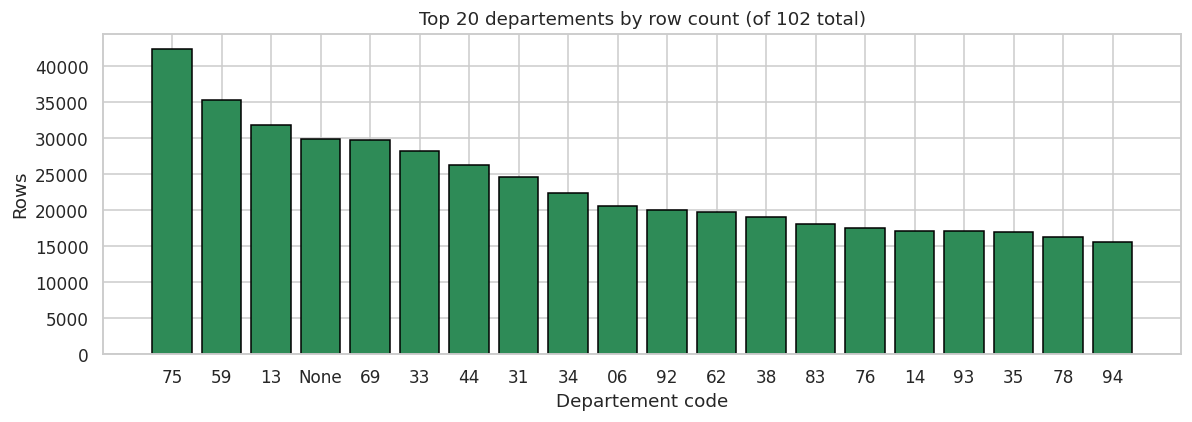

In [17]:
dept = df_clean["code_departement_ban"].astype(str).str.zfill(2)
top_depts = dept.value_counts().head(20)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(top_depts.index, top_depts.values, color="seagreen", edgecolor="black")
ax.set_title(f"Top 20 departements by row count (of {dept.nunique()} total)")
ax.set_ylabel("Rows")
ax.set_xlabel("Departement code")
fig.tight_layout()
fig.savefig(FIG_DIR / "geographic_distribution.png", dpi=120, bbox_inches="tight")
plt.show()

## Imputation and encoding

Two parallel feature matrices:
- **`X_tree`**: median-imputed numerics + ordinal-encoded categoricals (for random forest / gradient boosting).
- **`X_linear`**: median-imputed + standardised numerics + one-hot encoded categoricals (for ridge / logistic regression).

`X_imputed` is a third, human-readable version (imputed but not encoded) for downstream interpretation work.

In [18]:
X = df_clean[ALL_FEATURES].copy()
y_era = df_clean[TARGET_ERA].astype(str).copy()
y_binary = df_clean[TARGET_BINARY].astype(str).copy()
y_year = df_clean[TARGET_YEAR].copy()

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = [c for c in ALL_FEATURES if c not in numeric_features]
print(f"Numeric features:     {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
        ]), categorical_features),
    ],
    verbose_feature_names_out=False,
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", onehot),
        ]), categorical_features),
    ]
)

X_tree = pd.DataFrame(
    tree_preprocessor.fit_transform(X),
    columns=tree_preprocessor.get_feature_names_out(),
    index=X.index,
)
X_linear = pd.DataFrame(
    linear_preprocessor.fit_transform(X),
    columns=linear_preprocessor.get_feature_names_out(),
    index=X.index,
)

X_imputed = X.copy()
if numeric_features:
    X_imputed[numeric_features] = SimpleImputer(strategy="median").fit_transform(X[numeric_features])
if categorical_features:
    X_imputed[categorical_features] = SimpleImputer(strategy="most_frequent").fit_transform(X[categorical_features])

print()
print(f"Tree ordinal matrix:    {X_tree.shape}")
print(f"Linear one-hot matrix:  {X_linear.shape}")
print(f"Imputed (readable):     {X_imputed.shape}")

Numeric features:     14
Categorical features: 16

Tree ordinal matrix:    (993083, 30)
Linear one-hot matrix:  (993083, 495)
Imputed (readable):     (993083, 30)


## Train/test split

80/20 hold-out on the era target (the spec's primary target). 

In [19]:
indices = np.arange(len(df_clean))
train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    stratify=y_era,
    random_state=RANDOM_STATE,
)

split = pd.Series("train", index=df_clean.index, name="split")
split.iloc[test_idx] = "test"

print(f"Train rows: {len(train_idx):,} ({(1-TEST_SIZE)*100:.0f}%)")
print(f"Test rows:  {len(test_idx):,} ({TEST_SIZE*100:.0f}%)")
print()
print("Era distribution by split (proportion):")
print(pd.crosstab(split.values, y_era.values, normalize="index").round(3))

Train rows: 794,466 (80%)
Test rows:  198,617 (20%)

Era distribution by split (proportion):
col_0  1948-1974  1975-1988  1989-2000  2001-2012  2013+  pre-1948
row_0                                                             
test       0.294       0.14      0.095       0.12  0.046     0.304
train      0.294       0.14      0.095       0.12  0.046     0.304


## Save

Saves a single model-ready parquet plus the cleaning-log CSV to `data/cleaned/`. The parquet carries the raw (unencoded) features, all three targets, the `target_source` column, and the `split` column — everything `03_modeling_baselines.ipynb` needs. Encoding happens inside the modeling Pipelines (one preprocessor refit per CV fold) to avoid leakage, so the pre-encoded matrices `X_tree` / `X_linear` produced above are kept in-memory for inspection only and not written to disk.

In [20]:
model_ready = df_clean[[TARGET_YEAR, TARGET_ERA, TARGET_BINARY, "target_source"] + ALL_FEATURES].copy()
model_ready["split"] = split.values

out_path = CLEAN_DIR / "dpe_clean_model_ready.parquet"
model_ready.to_parquet(out_path, index=False)
print(f"- {out_path} ({out_path.stat().st_size / 1e6:.2f} MB)")

log_path = CLEAN_DIR / "cleaning_log.csv"
cleaning_report.to_csv(log_path, index=False)
print(f"- {log_path}")

- ../data/cleaned/dpe_clean_model_ready.parquet (36.30 MB)
- ../data/cleaned/cleaning_log.csv
